# Initialize Envirionment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
# !wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!cp /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.tgz .
!tar xf  spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

In [ ]:
import findspark
findspark.init()

In [ ]:
import pyspark
print(pyspark.__version__)

3.1.1


# **TASK 1**: Clustering
*dataset: mnist_mini.csv*

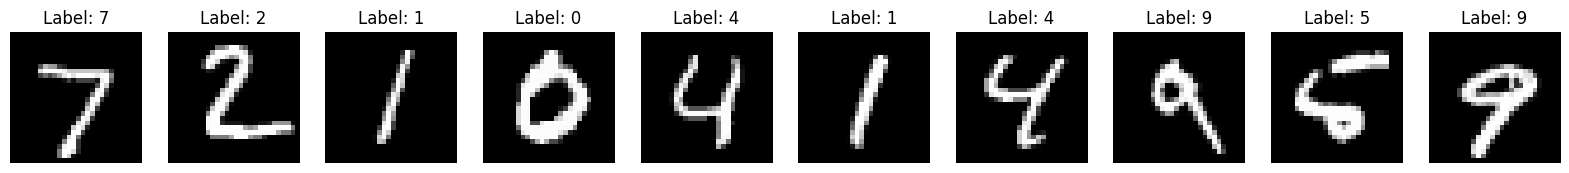

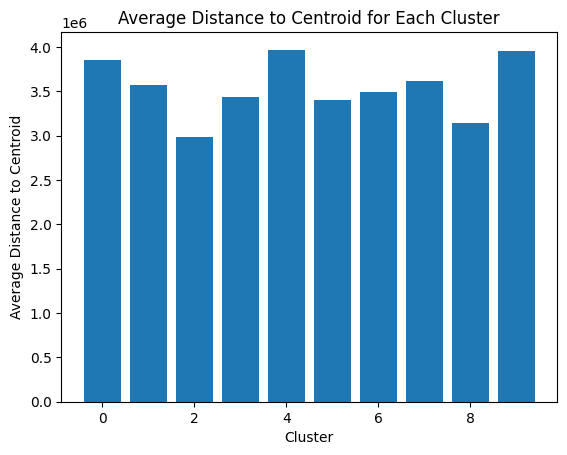

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import Row
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.linalg import Vectors,DenseVector
from pyspark.sql.functions import monotonically_increasing_id, col
import matplotlib.pyplot as plt
import numpy as np
class MNISTDataProcessorKMeans:
    def __init__(self):
        self.spark = SparkSession.builder.appName("MNISTProcessorApp").getOrCreate()
        self.df = None
        self.average_distances = []
        self.predictions = None

    def read_csv(self, file_path):
        # Read the CSV file into a DataFrame
        df = self.spark.read.csv(file_path, header=False, inferSchema=True)
        # Rename the first column to 'label'
        df = df.withColumnRenamed("_c0", "label")
        # Show the DataFrame
        #df.show(truncate=False)
        self.df = df
        return self.df
    def draw_mnist(self):
        # Lấy 10 dòng đầu tiên của DataFrame
        data = self.df.take(10)
        # Tạo figure để vẽ hình ảnh
        fig, axes = plt.subplots(1, 10, figsize=(20, 2))
        for i, row in enumerate(data):
            # Lấy vector đặc trưng và chuyển đổi thành mảng numpy
            image = np.array(row[1:]).reshape(28, 28)
            axes[i].imshow(image, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'Label: {row["label"]}')
        plt.show()
    def assign_weight(self):
        id = [0, 1, 2, 3, 4, 7, 8, 11, 18, 61]
        df_with_id = self.df.withColumn("id", monotonically_increasing_id())
        rdd = df_with_id.rdd.map(lambda row: Row(
            label=int(row.label),
            features=DenseVector(row[1:]),
            weight=(100.0 if row.id in id else 1.0)
        ))
        self.df_withAssgin = self.spark.createDataFrame(rdd)
        #self.df_withAssgin.show(70)
        return self.df_withAssgin

    def train(self, k=10):
        # Huấn luyện mô hình KMeans
        self.kmeans = KMeans().setK(k).setSeed(1).setWeightCol("weight")
        self.model = self.kmeans.fit(self.df_withAssgin)
        return self.model

    def average_distance_to_centroid(self, cluster):
        points = cluster.collect()
        centroid = self.model.clusterCenters()[cluster.first()['prediction']]
        distances = [Vectors.squared_distance(point['features'], centroid) for point in points]
        return sum(distances) / len(distances)

    def compute_average_distances(self):
        # Tính toán khoảng cách trung bình cho từng cluster
        self.predictions = self.model.transform(self.df_withAssgin)
        for i in range(10):
            cluster = self.predictions.filter(self.predictions.prediction == i)
            avg_dist = self.average_distance_to_centroid(cluster)
            self.average_distances.append(avg_dist)
        self.save_results()

    def save_results(self):
        # Add an 'id' column to the DataFrame
        self.predictions = self.predictions.withColumn("id", monotonically_increasing_id())
        # Convert the features column to string for CSV compatibility
        self.predictions = self.predictions.withColumn("features_str", col("features").cast("string"))
        # Select the required columns and write to CSV file
        self.predictions.select("id", "label", "features_str", "prediction").write.csv("/content/drive/MyDrive/clustering_results", header=True, mode="overwrite")

    def visualize(self):
        # Trực quan hóa khoảng cách trung bình
        plt.bar(range(10), self.average_distances)
        plt.xlabel('Cluster')
        plt.ylabel('Average Distance to Centroid')
        plt.title('Average Distance to Centroid for Each Cluster')
        plt.show()

    def run(self, file_path, k=10):
        self.read_csv(file_path)
        self.draw_mnist()
        self.assign_weight()
        self.train(k)
        self.compute_average_distances()
        self.visualize()

if __name__ == "__main__":
    file_path = "/content/drive/MyDrive/datasets/mnist_mini.csv"

    test = MNISTDataProcessorKMeans()
    test.run(file_path)

# **Task 2** Dimensionality Reduction with SVD
*dataset: mnist_mini.csv*

## Dimensionality reduction

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.ml.feature import VectorAssembler
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.linalg.distributed import RowMatrix

class SVDProcessor:
    def __init__(self, file_path, output_path):
        # Initialize Spark session
        self.spark = SparkSession.builder.appName("SVDProcessorApp").getOrCreate()
        self.file_path = file_path
        self.output_path = output_path
        self.df = None
        self.svd_result = None

    def read_data(self):
        # Read CSV file into a DataFrame and add an ID column
        df = self.spark.read.csv(self.file_path, header=False, inferSchema=True)
        df = df.withColumnRenamed("_c0", "label")
        df = df.withColumn("id", monotonically_increasing_id())
        self.df = df
        return self.df

    def prepare_data(self):
        # Prepare data using VectorAssembler to combine feature columns
        assembler = VectorAssembler(inputCols=self.df.columns[1:-1], outputCol="features")
        assembled_data = assembler.transform(self.df)
        return assembled_data

    def compute_svd(self, assembled_data, k=3):
        # Convert features to the format required by RowMatrix
        rows_rdd = assembled_data.select("features").rdd.map(lambda row: Vectors.dense(row[0].toArray()))
        # Create a RowMatrix and Compute SVD
        mat = RowMatrix(rows_rdd)
        svd = mat.computeSVD(k, computeU=True)
        U = svd.U
        # Convert U matrix to a DataFrame and add an ID column
        u_rows = U.rows.zipWithIndex().map(lambda x: Row(id=int(x[1]), svd1=float(x[0][0]), svd2=float(x[0][1]), svd3=float(x[0][2])))
        self.svd_result = self.spark.createDataFrame(u_rows)
        return self.svd_result

    def save_svd_result(self):
        # Save SVD result as a single CSV file
        self.svd_result.coalesce(1).write.csv(self.output_path, header=True, mode='overwrite')

    def load_data(self):
        self.svd_data = self.spark.read.csv(self.output_path, header=True, inferSchema=True)
        self.svd_data.show()
        return self.svd_data

    def run(self):
        # Run the entire SVD processing pipeline
        self.read_data()
        assembled_data = self.prepare_data()
        self.compute_svd(assembled_data)
        self.save_svd_result()
        self.load_data()

if __name__ == "__main__":
    file_path = "/content/drive/MyDrive/datasets/mnist_mini.csv"
    output_path = "/content/drive/MyDrive/svd_output"
    svd_processor = SVDProcessor(file_path, output_path)
    svd_processor.run()


+---+--------------------+--------------------+--------------------+
| id|                svd1|                svd2|                svd3|
+---+--------------------+--------------------+--------------------+
|  0|-0.00669131032125...|-0.00443905471561...|-0.01351694400004...|
|  1|-0.00850156910264...|0.002499996583745...| 0.01941258381610687|
|  2|-0.00410590493428...|-0.01023705818203...|0.008961557776589933|
|  3|-0.01405817161414...| 0.01828164590075766|-0.00180685774278...|
|  4|-0.00677704489082...|0.007715106136755821|-0.01436732453876049|
|  5|-0.00586935457332...|-0.01531273716859...|0.010168326808436882|
|  6|-0.00740645573953409|-0.00446959133274...|-0.01071474599212...|
|  7|-0.00774423691614...|-0.00521250540224...|-0.00626158073557...|
|  8|-0.01032632741854709|0.004305569043311...|-0.00373843930591...|
|  9|-0.01173561197044678|-0.00622930508353...|-0.01597488148864...|
| 10|-0.00896042297959...|0.023709537774818594|0.011211210806262941|
| 11|-0.00895826492210...| 0.00866

## Visualize

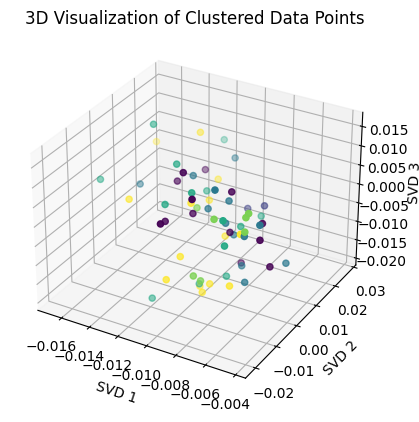

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import rand

class Visualizer:
    def __init__(self, svd_output_path, task1_output_path):
        # Initialize Spark session
        self.spark = SparkSession.builder.appName("VisualizerApp").getOrCreate()
        self.svd_output_path = svd_output_path
        self.task1_output_path = task1_output_path
        self.svd_data = None
        self.task1_data = None
        self.sampled_data = None

    def load_data(self):
        # Load SVD and Task 1 clustering results
        self.svd_data = self.spark.read.csv(self.svd_output_path, header=True, inferSchema=True)
        self.task1_data = self.spark.read.csv(self.task1_output_path, header=True, inferSchema=True)
        return self.svd_data, self.task1_data

    def sample_data(self):
        # Randomly sample 100 data points from SVD result
        self.sampled_data = self.svd_data.orderBy(rand()).limit(100)
        return self.sampled_data

    def visualize(self):
        # Join sampled SVD data with Task 1 clustering results
        joined_data = self.sampled_data.join(self.task1_data, on="id")
        # Convert to Pandas DataFrame for plotting
        pandas_df = joined_data.toPandas()
        # Create 3D scatter plot
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(pandas_df['svd1'], pandas_df['svd2'], pandas_df['svd3'], c=pandas_df['prediction'], cmap='viridis')
        ax.set_xlabel('SVD 1')
        ax.set_ylabel('SVD 2')
        ax.set_zlabel('SVD 3')
        plt.title('3D Visualization of Clustered Data Points')
        plt.show()

    def run(self):
        # Run the visualization process
        self.load_data()
        self.sample_data()
        self.visualize()

if __name__ == "__main__":
    svd_output_path = "/content/drive/MyDrive/svd_output"
    task1_path = "/content/drive/MyDrive/clustering_results"
    visualizer = Visualizer(svd_output_path, task1_path)
    visualizer.run()


# **TASK 3**  Recommendation with Collaborative Filtering
*dataset: ratings2k.csv*


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("CollaborativeFiltering").getOrCreate()

df = spark.read.csv("/content/drive/MyDrive/datasets/ratings2k.csv",header = True, inferSchema=True)
df.show()

+-----+----+----+------+
|index|user|item|rating|
+-----+----+----+------+
|    0|  73|  52|   4.0|
|    1|  36| 239|   3.0|
|    2|  72|  26|   1.0|
|    3|  59| 430|   2.5|
|    4|  72| 284|   3.0|
|    5|  36| 277|   3.0|
|    6|  72| 426|   4.0|
|    7|  18| 163|   3.0|
|    8|  67|  93|   4.0|
|    9|  59|  22|   3.5|
|   10|   8| 174|   2.0|
|   11|   5| 149|   2.0|
|   12|  26| 322|   3.5|
|   13|   8| 416|   4.0|
|   14|  31|  25|   2.0|
|   15|  41|  83|   2.0|
|   16|  25| 321|   3.0|
|   17|  47| 193|   3.0|
|   18|   9| 455|   4.0|
|   19|  43| 216|   3.5|
+-----+----+----+------+
only showing top 20 rows



Rank: 10, MSE: 1.217541550353672
Rank: 11, MSE: 1.2257129790911045
Rank: 12, MSE: 1.2554500692926422
Rank: 13, MSE: 1.2191499414384535
Rank: 14, MSE: 1.2316251660184723
Rank: 15, MSE: 1.2010920298205943
Rank: 16, MSE: 1.2211021784013907
Rank: 17, MSE: 1.2203811295509794
Rank: 18, MSE: 1.201800285509657
Rank: 19, MSE: 1.2236828586518593
Rank: 20, MSE: 1.2194184952093328


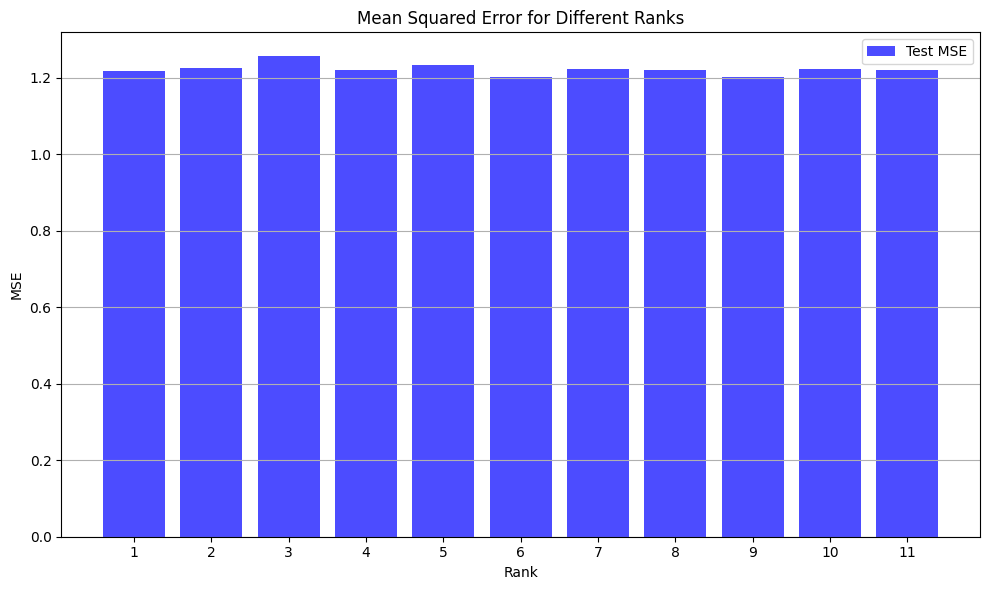

In [ ]:
class RecommendationSystem:
    def __init__(self, dataframe):
        self.df = dataframe
        self.als = ALS(
            maxIter=10,
            regParam=0.1,
            userCol="user",
            itemCol="item",
            ratingCol="rating",
            coldStartStrategy="drop"
        )
        self.evaluator = RegressionEvaluator(
            metricName="mse",
            labelCol="rating",
            predictionCol="prediction"
        )
        self.model = None
        self.test_mse_list = []

    def split_data(self, train_fraction=0.7):
        self.train_data, self.test_data = self.df.randomSplit(weights=[train_fraction, 1 - train_fraction])

    def train_model(self, rank):
        self.als.setRank(rank)
        self.model = self.als.fit(self.train_data)

    def evaluate_model(self):
        predictions = self.model.transform(self.test_data)
        mse = self.evaluator.evaluate(predictions)
        return mse

    def train(self, min_users=10, max_users=20):
        num_users = self.df.select('user').distinct().count()
        if num_users < max_users:
            max_users = num_users
        ranks = range(min_users, max_users + 1)
        for rank in ranks:
            self.train_model(rank)
            mse = self.evaluate_model()
            self.test_mse_list.append(mse)
            print(f"Rank: {rank}, MSE: {mse}")

    def draw(self):
        plt.figure(figsize=(10, 6))
        ranks = range(1, len(self.test_mse_list) + 1)
        plt.bar(ranks, self.test_mse_list, color='blue', alpha=0.7, label='Test MSE')
        plt.xticks(ranks)
        plt.legend()
        plt.ylabel('MSE')
        plt.xlabel('Rank')
        plt.title('Mean Squared Error for Different Ranks')
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()


    def run(self):
        self.split_data()
        self.train()
        self.draw()

# Create instance of RecommendationSystem
recommender = RecommendationSystem(df)

# Run the recommendation system
recommender.run()

# **TASK 4**: Stock price regression.
*dataset: stockHVN2022.csv*

## Documentation

This task use Pyspark to implement a Linear regression model to predict range of fluctuate of the next day by given *k* days previous

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!tar xf /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [ ]:
# Create a spark session
spark = SparkSession.builder.appName("StockPricePrediction").getOrCreate()

In [ ]:
# Data_path
data_path = '/content/drive/MyDrive/datasets/stockHVN2022.csv'

In [ ]:
# Import libraries
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.functions import array_to_vector
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import col, to_date, desc, sum, lag, round, array, lead
import matplotlib.pyplot as plt

## Data Preprocessing

In [ ]:
class DataPreparation:
  def __init__(self, file_path, k=1):
    self.df = None
    self.spark = spark
    self.file_path = file_path
    self.k = k
    self.train_df = None
    self.test_df = None
    self.feature_train_df = None
    self.feature_test_df = None

  def load_data(self):
    self.df = self.spark.read.csv(data_path, header=True, inferSchema=True)

    # Convert 'Ngay' column to date format
    self.df = self.df.withColumn('Ngay', to_date(col('Ngay'),'dd/MM/yyyy'))

    # Display the first 5 rows of the DataFrame
    self.df.show(5)

    # Display DataFrame schema to check the schema
    self.df.printSchema()

  def train_test_split(self):
    if self.df is None:
      raise ValueError('Data not loaded')

    self.train_df = self.df.filter((col('Ngay') <= '2022-06-30'))
    self.test_df = self.df.filter(col('Ngay') > '2022-06-30')

    print("Train data:")
    self.train_df.show(5)
    print("Test data:")
    self.test_df.show(5)

  @staticmethod
  def calculate_fluctuation(df, k):
    window_spec = Window.rowsBetween(0, k)
    pre_window_spec = Window.rowsBetween(0, k-1)

    # Collect the HVN values of the next k rows into an array
    df = df.withColumn('new_HVN',sum(col('HVN')).over(window_spec))
    df = df.withColumn('pre_HVN', sum(col('HVN')).over(pre_window_spec))
    df = df.withColumn('fluctuation', (col('new_HVN') - col('pre_HVN')) / col('pre_HVN'))
    # df = df.withColumn('fluctuation', round(col('fluctuation'),10)*100)
    df = df.na.fill(0,"fluctuation")
    df = df.select("Ngay","HVN","fluctuation")
    return df

  def create_fluctuation(self):
    # Calculate fluctuation for both training and test sets
    self.train_df = self.calculate_fluctuation(self.train_df,self.k)
    self.test_df = self.calculate_fluctuation(self.test_df,self.k)

    # Display the first 5 rows of the updated DataFrames
    print('Train dataframe after add fluctuation col')
    self.train_df.show(10,truncate=False)
    print('Test dataframe after add fluctuation col')
    self.test_df.show(10, truncate=False)

    # check last rows
    # print('check last rows')
    # self.train_df.orderBy('Ngay').show(10)


  @staticmethod
  def define_feature_df(df):

    window_spec = Window.orderBy(desc('Ngay'))

    for i in range(1,6):
      df = df.withColumn(f"fluctuation_{i}", lead(col('fluctuation'),i).over(window_spec))
      df = df.na.fill(0,subset=[f"fluctuation_{i}"])

    df = df.withColumn("temp_range_arr", array([col(f"fluctuation_{i}") for i in range(1,6)]))
    df = df.withColumn("range_of_5_previous_dates", array_to_vector("temp_range_arr"))
    df = df.withColumn('today_range', lag(col('fluctuation')).over(window_spec))
    df = df.select("range_of_5_previous_dates","today_range")
    df = df.na.fill(0,subset=["today_range"])

    return df

  def create_feature_df(self):
    self.feature_train_df = self.define_feature_df(self.train_df)
    self.feature_test_df = self.define_feature_df(self.test_df)

    print("Check")
    self.feature_train_df.show(10,truncate=False)
    self.feature_test_df.show(10,truncate=False)


## Training and Evaluating Linear Regression model with MSE loss

In [ ]:
class ModelTraining:
    def __init__(self):
        self.model = None
        self.train_mse = None
        self.test_mse = None

    def train_model(self, train_df):
        # Transform training set
        assembler = VectorAssembler(inputCols=['range_of_5_previous_dates'], outputCol='features')
        train_data = assembler.transform(train_df).select(col('features'), col('today_range').alias('label'))

        # Initialize and train the Linear Regression model
        model = LinearRegression(featuresCol="features", labelCol="label")
        self.model = model.fit(train_data)

        # Evaluate the model on training data
        train_predictions = self.model.transform(train_data)
        self.train_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse").evaluate(train_predictions)
        print(f"Training MSE: {self.train_mse}")

    def evaluate_model(self, test_df):
        # Make sure the model is trained
        if self.model is None:
            raise ValueError("Model not trained")

        # Transform test set
        assembler = VectorAssembler(inputCols=['range_of_5_previous_dates'], outputCol='features')
        test_data = assembler.transform(test_df).select(col('features'), col('today_range').alias('label'))

        # Evaluate the model on test data
        test_predictions = self.model.transform(test_data)
        self.test_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse").evaluate(test_predictions)
        print(f"Test MSE: {self.test_mse}")

    def plot_mse(self):
        # Ensure the MSE values are available
        if self.train_mse is None or self.test_mse is None:
            raise ValueError("MSE values not available. Ensure model is trained and evaluated before plotting.")

        # Plot MSE values
        sets = ['Train', 'Test']
        mse_values = [self.train_mse, self.test_mse]

        plt.figure(figsize=(10, 5))
        plt.bar(sets, mse_values, color=['blue', 'green'])
        plt.xlabel('Dataset')
        plt.ylabel('Mean Squared Error')
        plt.title('MSE for Training and Test Sets')
        plt.show()



## Running

+----------+----+
|      Ngay| HVN|
+----------+----+
|2022-11-18| 9.3|
|2022-11-17|9.42|
|2022-11-16|9.21|
|2022-11-15|8.61|
|2022-11-14|9.25|
+----------+----+
only showing top 5 rows

root
 |-- Ngay: date (nullable = true)
 |-- HVN: double (nullable = true)

Train data:
+----------+-----+
|      Ngay|  HVN|
+----------+-----+
|2022-06-30| 15.5|
|2022-06-29|16.05|
|2022-06-28| 16.5|
|2022-06-27| 16.3|
|2022-06-24|15.25|
+----------+-----+
only showing top 5 rows

Test data:
+----------+----+
|      Ngay| HVN|
+----------+----+
|2022-11-18| 9.3|
|2022-11-17|9.42|
|2022-11-16|9.21|
|2022-11-15|8.61|
|2022-11-14|9.25|
+----------+----+
only showing top 5 rows

Train dataframe after add fluctuation col
+----------+-----+--------------------+
|Ngay      |HVN  |fluctuation         |
+----------+-----+--------------------+
|2022-06-30|15.5 |0.024157729390098533|
|2022-06-29|16.05|0.02424991934616621 |
|2022-06-28|16.5 |0.024989320803075588|
|2022-06-27|16.3 |0.02544259514470476 |
|2022-06-2

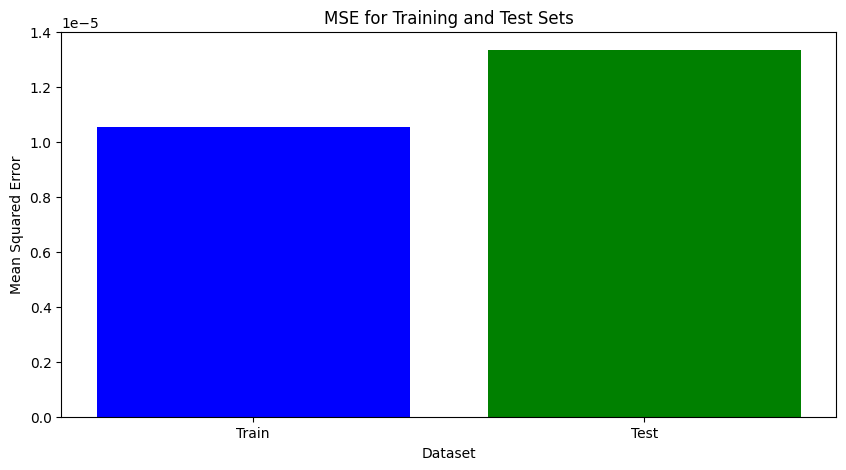

In [ ]:
if __name__ == "__main__":
  data_prep = DataPreparation(data_path, 50) # k = 50, default = 1 can adjust this one
  # Load, split, and prepare data
  data_prep.load_data()
  data_prep.train_test_split()

  # create fluctuation col
  data_prep.create_fluctuation()
  print(type(data_prep.train_df))
  data_prep.train_df.printSchema()

  # create feature df
  data_prep.create_feature_df()

  # Initialize ModelTraining
  model_training = ModelTraining()

  # Train and evaluate the model
  model_training.train_model(data_prep.feature_train_df)
  model_training.evaluate_model(data_prep.feature_test_df)

  # Plot the MSE values
  model_training.plot_mse()

# **Task 5:** Multi-class classification
*dataset: mnist_mini.csv*

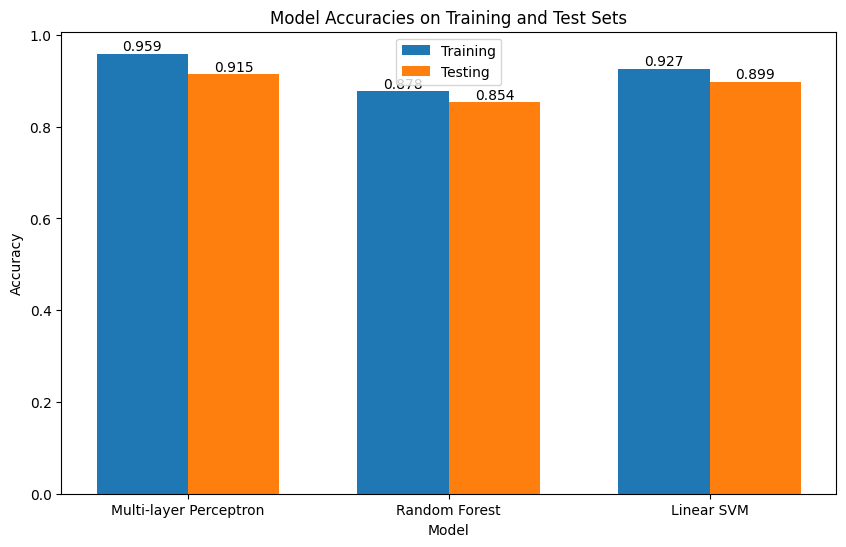

In [ ]:
import matplotlib.pyplot as plt
from pyspark.ml import Pipeline
from pyspark.ml.classification import MultilayerPerceptronClassifier, RandomForestClassifier, LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql import SparkSession

class MNISTClassifier:
    def __init__(self, spark, data_path):
        self.spark = spark
        self.data_path = data_path
        self.data = None
        self.train_data = None
        self.test_data = None
        self.mlp_model = None
        self.rf_model = None
        self.svm_model = None

    def load_data(self):
        # Load the data
        self.data = self.spark.read.csv(self.data_path, header=False, inferSchema=True)

        # Rename columns
        column_names = self.data.columns
        new_column_names = ["label"] + [f"pixel_{i}" for i in range(1, len(column_names))]
        self.data = self.data.toDF(*new_column_names)

        # Index labels
        label_indexer = StringIndexer(inputCol="label", outputCol="label_idx")
        self.data = label_indexer.fit(self.data).transform(self.data)

        # Assemble features
        vector_assembler = VectorAssembler(inputCols=[f"pixel_{i}" for i in range(1, 785)], outputCol="features")
        self.data = vector_assembler.transform(self.data)

        # Split data into training and testing sets
        self.train_data, self.test_data = self.data.randomSplit([0.8, 0.2], seed=1234)

    def train_model(self, classifier):
        pipeline = Pipeline(stages=[classifier])
        model = pipeline.fit(self.train_data)
        return model

    def evaluate_model(self, model):
        evaluator = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
        train_accuracy = evaluator.evaluate(model.transform(self.train_data))
        test_accuracy = evaluator.evaluate(model.transform(self.test_data))
        return train_accuracy, test_accuracy

    def plot_accuracies(self, accuracies):
        models = ["Multi-layer Perceptron", "Random Forest", "Linear SVM"]
        train_accuracies, test_accuracies = zip(*accuracies)

        fig, ax = plt.subplots(figsize=(10, 6))
        bar_width = 0.35
        index = range(len(models))

        train_bars = ax.bar(index, train_accuracies, bar_width, label="Training")
        test_bars = ax.bar([i + bar_width for i in index], test_accuracies, bar_width, label="Testing")

        ax.set_xlabel("Model")
        ax.set_ylabel("Accuracy")
        ax.set_title("Model Accuracies on Training and Test Sets")
        ax.set_xticks([i + bar_width / 2 for i in index])
        ax.set_xticklabels(models)
        ax.legend()

        for train_bar, test_bar in zip(train_bars, test_bars):
            ax.text(
                train_bar.get_x() + train_bar.get_width() / 2,
                train_bar.get_height(),
                f"{train_bar.get_height():.3f}",
                ha="center",
                va="bottom",
            )
            ax.text(
                test_bar.get_x() + test_bar.get_width() / 2,
                test_bar.get_height(),
                f"{test_bar.get_height():.3f}",
                ha="center",
                va="bottom",
            )

        plt.show()

    def run(self):
        self.load_data()

        # Define classifiers
        mlp = MultilayerPerceptronClassifier(featuresCol="features", labelCol="label_idx", maxIter=100, layers=[784, 128, 10], blockSize=128, seed=1234)
        rf = RandomForestClassifier(featuresCol="features", labelCol="label_idx", numTrees=100, seed=1234)

        # One-vs-Rest with Linear SVM
        lsvc = LinearSVC(featuresCol="features", labelCol="label_idx", maxIter=100, regParam=0.1)
        ovr = OneVsRest(classifier=lsvc, labelCol="label_idx", featuresCol="features")

        # Train and evaluate models
        classifiers = [mlp, rf, ovr]
        accuracies = []
        for classifier in classifiers:
            model = self.train_model(classifier)
            train_accuracy, test_accuracy = self.evaluate_model(model)
            accuracies.append((train_accuracy, test_accuracy))

        # Plot accuracies
        self.plot_accuracies(accuracies)

if __name__ == "__main__":
    spark = SparkSession.builder.appName("MNIST Classifiers").getOrCreate()
    data_path = "/content/drive/MyDrive/datasets/mnist_mini.csv"
    mnist_classifier = MNISTClassifier(spark, data_path)
    mnist_classifier.run()
